# 05 · The same validation toolkit on a small bank portfolio: market-risk VaR, P&L attribution and IRRBB

Results and interpretation: [results_analysis.md](../results_analysis.md)

## 0. Settings

In [1]:
import sys
from functools import partial
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

ROOT = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
FIG = ROOT / "figures"
FIG.mkdir(exist_ok=True)
plt.rcParams.update({"figure.figsize": (9, 4.5), "axes.spines.top": False, "axes.spines.right": False})

sys.path.insert(0, str(ROOT / "src"))   # pricing, tests and helpers shared with the other notebooks
import backtests  # noqa: E402
from backtests import traffic_light  # noqa: E402
from bank_products import (bond_value, fx_forward_strike, fx_forward_value, interpolation_matrix,  # noqa: E402
                           par_rate, payer_swap_value, shocked_rates, supervisory_shocks)
from notebook_tools import p_text, save_figure  # noqa: E402

save = partial(save_figure, folder=FIG)

# Settings fixed before any result was computed.
DATA = ROOT / "data" / "raw" / "ecb"
TENORS = np.array([0.25, 0.5, 1, 2, 3, 5, 7, 10, 15, 20, 30])   # front-office curves: all 11 tenors
RISK_NODES = np.array([1, 2, 5, 10, 30])                         # the risk model: five nodes of the AAA curve
INCEPTION = "2018-12-31"     # contract terms (coupon, fixed rate, FX strike) are set at par on this day
BOND = {"notional": 10e6, "maturity": 10}             # long a 10-year euro-area government bond
SWAP = {"notional": 20e6, "maturity": 5}              # pay fixed on a 5-year interest rate swap
FX_FORWARD = {"usd_notional": 10e6, "maturity": 0.5}  # receive 10 million US dollars in 6 months against euros
USD_RATE = 0.04              # no US dollar curve in the data: a constant rate, a risk factor left out on purpose
WINDOW = 250                 # business days of history for historical simulation
VAR_LEVEL, ES_LEVEL = 0.99, 0.975
BACKTEST = ("2019-01-01", "2026-09-30")
STRESS_WINDOW = ("2022-01-01", "2022-12-31")          # the 2022 rise in euro rates
HORIZON = 10                                           # days, for the 10-day VaR
PLA_GREEN = {"spearman": 0.80, "ks": 0.09}             # FRTB P&L attribution test: green zone
PLA_AMBER = {"spearman": 0.70, "ks": 0.12}             # amber zone; anything worse is red
SEED = 42

# IRRBB: a stylised banking book in million euros; its behavioural assumptions are part of the model
TIER1 = 100.0
ASSETS = {"fixed-rate mortgages": dict(amount=500.0, rate=0.035, years=15, kind="annuity"),
          "floating-rate loans": dict(amount=300.0, rate=0.040, years=0.25, kind="bullet"),
          "government bonds": dict(amount=150.0, rate=0.025, years=5, kind="bullet")}
LIABILITIES = {"non-maturity deposits, non-core": dict(amount=200.0, rate=0.000, years=0.0, kind="bullet"),
               "non-maturity deposits, core": dict(amount=300.0, rate=0.005, years=5, kind="spread"),
               "term deposits": dict(amount=250.0, rate=0.030, years=1, kind="bullet"),
               "senior bonds issued": dict(amount=100.0, rate=0.032, years=5, kind="bullet")}
HEDGE = {"notional": 250.0, "maturity": 7}    # a banking-book swap that pays fixed (at par) and receives floating
HEDGE_VARIANTS = [0.0, 250.0, 500.0]          # hedge sizes for the sensitivity of the worst ΔEVE
DEPOSIT_PASS_THROUGH = 0.5                    # share of a rate change passed on to non-maturity deposits within a year
EVE_OUTLIER, NII_OUTLIER = 0.15, 0.05         # EBA supervisory outlier tests, as shares of Tier 1 capital
assets_total = sum(i["amount"] for i in ASSETS.values())
liabilities_total = sum(i["amount"] for i in LIABILITIES.values())
assert assets_total == liabilities_total + TIER1, "the stylised balance sheet must balance"

## 1. Data

In [2]:
raw = pd.read_csv(DATA / "yield_curve.csv", parse_dates=["date"])
curves = {name: part.pivot(index="date", columns="tenor_years", values="rate_pct").reindex(columns=TENORS) / 100
          for name, part in raw.groupby("curve")}          # decimal, continuously compounded zero rates
fx = pd.read_csv(DATA / "eurusd.csv", parse_dates=["date"]).set_index("date")["usd_per_eur"]
DATES = (curves["AAA"].dropna().index.intersection(curves["all"].dropna().index)
         .intersection(fx.dropna().index).sort_values())
AAA, GOVT, FX = curves["AAA"].loc[DATES].to_numpy(), curves["all"].loc[DATES].to_numpy(), fx.loc[DATES].to_numpy()
spread_10y = pd.Series(GOVT[:, TENORS == 10][:, 0] - AAA[:, TENORS == 10][:, 0], index=DATES)
print(f"{len(DATES):,} days with both curves and an exchange rate, {DATES.min().date()} – {DATES.max().date()}")
print(f"10-year spread of all euro-area governments over AAA: {1e4 * spread_10y.min():.0f}–{1e4 * spread_10y.max():.0f} bp, "
      f"last {1e4 * spread_10y.iloc[-1]:.0f} bp")
pd.DataFrame({"AAA 2-year": AAA[:, TENORS == 2][:, 0], "AAA 10-year": AAA[:, TENORS == 10][:, 0],
              "all governments 10-year": GOVT[:, TENORS == 10][:, 0], "USD per EUR": FX},
             index=DATES).iloc[[0, -1]].round(4)

2,997 days with both curves and an exchange rate, 2015-01-02 – 2026-09-30
10-year spread of all euro-area governments over AAA: 31–105 bp, last 55 bp


,AAA 2-year,AAA 10-year,all governments 10-year,USD per EUR
date,,,,
2015-01-02,-0.0012,0.0061,0.0116,1.2043
2026-09-30,0.0316,0.0358,0.0413,1.1355


## 2. Portfolio and full revaluation

In [3]:
NODE_IDX = [int(np.where(TENORS == n)[0][0]) for n in RISK_NODES]
NODES_TO_CURVE = interpolation_matrix(RISK_NODES, TENORS)


def risk_model_curve(rates):
    # The curve as the risk model sees it: the five nodes are risk factors, the other tenors are interpolated.
    return np.asarray(rates)[..., NODE_IDX] @ NODES_TO_CURVE.T


start = DATES.get_indexer([pd.Timestamp(INCEPTION)], method="pad")[0]
TERMS = {"coupon": float(par_rate(GOVT[start], TENORS, BOND["maturity"])),
         "fixed_rate": float(par_rate(AAA[start], TENORS, SWAP["maturity"])),
         "strike_eur": float(fx_forward_strike(AAA[start], TENORS, FX[start], FX_FORWARD["usd_notional"],
                                               FX_FORWARD["maturity"], USD_RATE))}


def positions(aaa, govt, usd_per_eur):
    # Values in euros, for one market state or many (rows). The bond is valued on the curve of all euro-area
    # governments; the swap and the FX forward on the AAA curve, the closest the data have to a swap curve.
    # The portfolio keeps a constant maturity, so P&L comes from market moves, not from the positions ageing.
    return {"bond": bond_value(govt, TENORS, BOND["notional"], TERMS["coupon"], BOND["maturity"]),
            "swap": payer_swap_value(aaa, TENORS, SWAP["notional"], TERMS["fixed_rate"], SWAP["maturity"]),
            "fx forward": fx_forward_value(aaa, TENORS, usd_per_eur, FX_FORWARD["usd_notional"],
                                           TERMS["strike_eur"], FX_FORWARD["maturity"], USD_RATE)}


def front_office(aaa, govt, usd_per_eur):
    return sum(positions(aaa, govt, usd_per_eur).values())


def risk_model(aaa, usd_per_eur):
    # The bank's risk model: five AAA nodes and the exchange rate. It maps the bond to the AAA curve, a proxy that
    # leaves out the sovereign spread.
    curve = risk_model_curve(aaa)
    return sum(positions(curve, curve, usd_per_eur).values())


value_fo = pd.Series(front_office(AAA, GOVT, FX), index=DATES)
value_rm = pd.Series(risk_model(AAA, FX), index=DATES)
print({k: round(v, 5) for k, v in TERMS.items()})
print(f"Front-office value on the inception day: {value_fo.iloc[start]:,.0f} €; on the last day: {value_fo.iloc[-1]:,.0f} €")

{'coupon': 0.01145, 'fixed_rate': -0.00261, 'strike_eur': 8524160.62308}
Front-office value on the inception day: 10,000,000 €; on the last day: 11,045,030 €


## 3. Historical-simulation VaR and ES, and their backtest

In [4]:
# Daily risk-factor changes: absolute for rates (they were negative for years), logarithmic for the exchange rate.
D_AAA, D_GOVT, D_LOGFX = np.diff(AAA, axis=0), np.diff(GOVT, axis=0), np.diff(np.log(FX))   # row i: day i -> i + 1


def scenario_pnl(t, rows, model="risk model"):
    # P&L distribution for day t, forecast at the close of day t - 1: the changes in `rows` applied to the market of
    # day t - 1, and the portfolio revalued in full by the risk model or with the front-office risk factors.
    aaa, govt, usd = AAA[t - 1] + D_AAA[rows], GOVT[t - 1] + D_GOVT[rows], FX[t - 1] * np.exp(D_LOGFX[rows])
    if model == "risk model":
        return risk_model(aaa, usd) - risk_model(AAA[t - 1], FX[t - 1])
    return front_office(aaa, govt, usd) - front_office(AAA[t - 1], GOVT[t - 1], FX[t - 1])


def var_es(pnl, var_level=VAR_LEVEL, es_level=ES_LEVEL):
    return -np.quantile(pnl, 1 - var_level), -pnl[pnl <= np.quantile(pnl, 1 - es_level)].mean()


first = DATES.get_indexer([pd.Timestamp(BACKTEST[0])], method="backfill")[0]
last = DATES.get_indexer([pd.Timestamp(BACKTEST[1])], method="pad")[0]
stress_rows = np.where((DATES[1:] >= STRESS_WINDOW[0]) & (DATES[1:] <= STRESS_WINDOW[1]))[0]
hpl = np.diff(value_fo.to_numpy())                     # hypothetical P&L: front-office revaluation
rows, samples = [], []
for t in range(first, last + 1):
    window = np.arange(t - 1 - WINDOW, t - 1)
    model = scenario_pnl(t, window)
    var, es = var_es(model)
    rows.append({"date": DATES[t], "HPL": hpl[t - 1], "VaR 99%": var, "VaR 97.5%": var_es(model, var_level=ES_LEVEL)[0],
                 "ES 97.5%": es, "VaR 99%, front-office risk factors": var_es(scenario_pnl(t, window, "front office"))[0],
                 "stressed VaR 99%": var_es(scenario_pnl(t, stress_rows))[0]})
    samples.append(model)
risk = pd.DataFrame(rows).set_index("date")
print(f"{len(risk):,} backtest days, {risk.index.min().date()} – {risk.index.max().date()}")

results = []
for level, column in [(0.99, "VaR 99%"), (0.975, "VaR 97.5%"), (0.99, "VaR 99%, front-office risk factors")]:
    hits = (risk["HPL"] < -risk[column]).astype(int)
    res = backtests.backtest(hits.to_numpy(), 1 - level)
    res["zones by year"] = ", ".join(f"{y}: {traffic_light(h.sum(), len(h), 1 - level)}" for y, h in hits.groupby(hits.index.year))
    results.append({"VaR": column, **res})
var_results = pd.DataFrame(results)
display(var_results.drop(columns="expected").round(3))
z2, p_z2 = backtests.acerbi_szekely_z2(risk["HPL"], risk["VaR 97.5%"], risk["ES 97.5%"], samples,
                                        alpha=1 - ES_LEVEL, seed=SEED)
print(f"Expected Shortfall 97.5%: Acerbi–Szekely Z2 = {z2:.2f} (p = {p_text(p_z2)})")
(risk.assign(exception=risk["HPL"] < -risk["VaR 99%"]).groupby(risk.index.year)
     .agg(days=("HPL", "size"), exceptions=("exception", "sum"), average_VaR=("VaR 99%", "mean"),
          average_stressed_VaR=("stressed VaR 99%", "mean")).round(0))

1,978 backtest days, 2019-01-02 – 2026-09-30


,VaR,days,hits,hit rate,binomial p,Kupiec p,Christoffersen p,conditional coverage p,zone,zones by year
0,VaR 99%,1978,42,0.021,0.000,0.000,0.070,0.000,red,"2019: yellow, 2020: red, 2021: green, 2022: ye..."
1,VaR 97.5%,1978,81,0.041,0.000,0.000,0.063,0.000,red,"2019: yellow, 2020: red, 2021: green, 2022: re..."
2,"VaR 99%, front-office risk factors",1978,32,0.016,0.009,0.011,0.305,0.024,yellow,"2019: green, 2020: yellow, 2021: green, 2022: ..."


Expected Shortfall 97.5%: Acerbi–Szekely Z2 = -0.91 (p = <0.001)


,days,exceptions,average_VaR,average_stressed_VaR
date,,,,
2019,253,8,74393.0,128844.0
2020,255,13,101982.0,126940.0
2021,257,1,82450.0,123614.0
2022,257,9,96861.0,137646.0
2023,255,2,150241.0,135044.0
2024,255,1,111753.0,134993.0
2025,255,7,116886.0,130463.0
2026,191,1,105530.0,126938.0


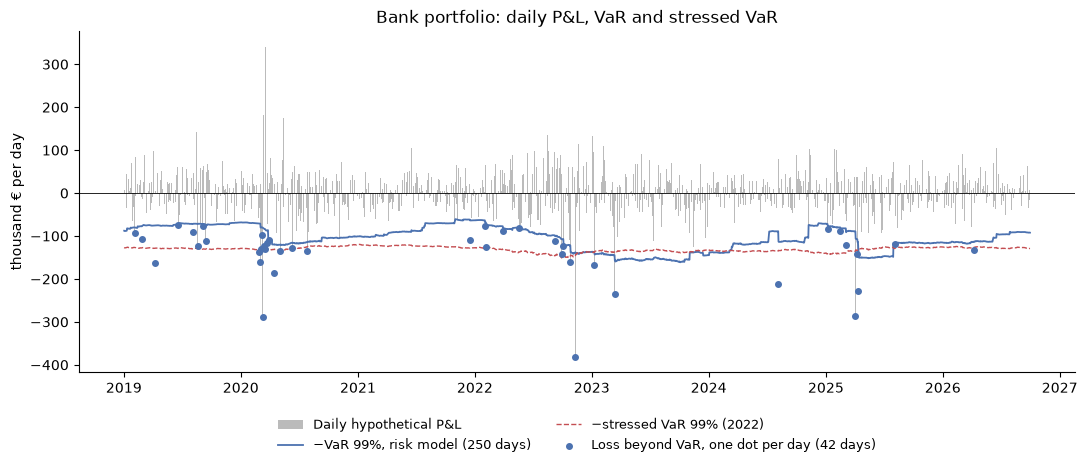

In [5]:
fig, ax = plt.subplots(figsize=(11, 4.8))
bars = ax.bar(risk.index, risk["HPL"] / 1e3, color="#bbbbbb", width=1.5, label="Daily hypothetical P&L")
line, = ax.plot(risk.index, -risk["VaR 99%"] / 1e3, color="#4c72b0", lw=1.3, label="−VaR 99%, risk model (250 days)")
stress_line, = ax.plot(risk.index, -risk["stressed VaR 99%"] / 1e3, color="#c44e52", lw=1.0, ls="--",
                       label="−stressed VaR 99% (2022)")
breaks = risk["HPL"] < -risk["VaR 99%"]
dots = ax.scatter(risk.index[breaks], risk.loc[breaks, "HPL"] / 1e3, color="#4c72b0", s=16, zorder=3,
                  label=f"Loss beyond VaR, one dot per day ({int(breaks.sum())} days)")
ax.axhline(0, color="black", lw=0.6)
ax.set(ylabel="thousand € per day", title="Bank portfolio: daily P&L, VaR and stressed VaR")
ax.legend(handles=[bars, line, stress_line, dots], loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=2,
          frameon=False, fontsize=9)
fig.tight_layout()
save(fig, "q5_var_backtest")
plt.show()

## 4. Stressed VaR and the 10-day horizon

In [6]:
# 10-day VaR two ways: the square-root-of-time rule, and historical simulation on overlapping 10-day changes
ten_day = []
for t in range(first, last + 1, 20):                     # every 20th day is enough to compare the two
    starts = np.arange(t - 1 - WINDOW, t - HORIZON)
    aaa = AAA[t - 1] + np.array([D_AAA[s:s + HORIZON].sum(axis=0) for s in starts])
    usd = FX[t - 1] * np.exp(np.array([D_LOGFX[s:s + HORIZON].sum() for s in starts]))
    pnl10 = risk_model(aaa, usd) - risk_model(AAA[t - 1], FX[t - 1])
    ten_day.append({"date": DATES[t], "sqrt(10) x 1-day VaR": np.sqrt(HORIZON) * risk.loc[DATES[t], "VaR 99%"],
                    "10-day VaR, overlapping changes": -np.quantile(pnl10, 1 - VAR_LEVEL)})
ten_day = pd.DataFrame(ten_day).set_index("date")
ratio = ten_day["10-day VaR, overlapping changes"] / ten_day["sqrt(10) x 1-day VaR"]
stressed_ratio = risk["stressed VaR 99%"] / risk["VaR 99%"]
fo_ratio = risk["VaR 99%, front-office risk factors"] / risk["VaR 99%"]
print(f"10-day VaR from overlapping changes against the square-root rule: median ratio {ratio.median():.2f}, "
      f"range {ratio.min():.2f}–{ratio.max():.2f}")
print(f"Stressed VaR against VaR: median ratio {stressed_ratio.median():.2f}; "
      f"VaR with the front-office risk factors against the risk model: median ratio {fo_ratio.median():.2f}")
ten_day.resample("YE").mean().round(0)

10-day VaR from overlapping changes against the square-root rule: median ratio 0.87, range 0.47–1.23
Stressed VaR against VaR: median ratio 1.19; VaR with the front-office risk factors against the risk model: median ratio 1.08


,sqrt(10) x 1-day VaR,"10-day VaR, overlapping changes"
date,,
2019-12-31,237577.0,187445.0
2020-12-31,321760.0,312249.0
2021-12-31,260185.0,253868.0
2022-12-31,314380.0,248369.0
2023-12-31,474814.0,351441.0
2024-12-31,354402.0,298299.0
2025-12-31,364540.0,398063.0
2026-12-31,335311.0,312322.0


## 5. P&L attribution test

P&L attribution zones over 28 quarters: {'green': 26, 'amber': 2}
The unexplained P&L (HPL − RTPL) against the change in the 10-year sovereign spread: R² = 0.97


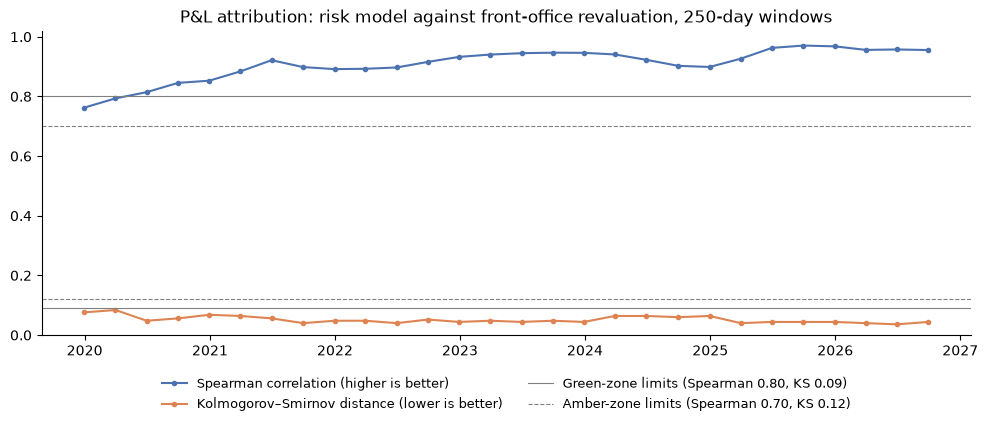

,Spearman,Kolmogorov–Smirnov,zone
quarter end,,,
2019-12-30,0.762,0.076,amber
2020-03-31,0.793,0.084,amber
2020-06-30,0.814,0.048,green
2020-09-30,0.845,0.056,green
2020-12-30,0.853,0.068,green
2021-03-31,0.884,0.064,green
2021-06-30,0.921,0.056,green
2021-09-30,0.898,0.040,green
2021-12-31,0.891,0.048,green


In [7]:
# Risk-theoretical P&L (RTPL): the P&L the risk model sees; hypothetical P&L (HPL): front-office revaluation.
pla = pd.DataFrame({"HPL": hpl, "RTPL": np.diff(value_rm.to_numpy()),
                    "spread change": np.diff(spread_10y.to_numpy())}, index=DATES[1:]).loc[BACKTEST[0]:BACKTEST[1]]


def pla_zone(spearman, ks):
    if spearman >= PLA_GREEN["spearman"] and ks <= PLA_GREEN["ks"]:
        return "green"
    return "amber" if spearman >= PLA_AMBER["spearman"] and ks <= PLA_AMBER["ks"] else "red"


quarter_ends = pla.index.to_series().groupby(pla.index.to_period("Q")).max()
windows = []
for end in quarter_ends:
    part = pla.loc[:end].tail(250)
    if len(part) < 250:
        continue
    rho = stats.spearmanr(part["HPL"], part["RTPL"]).statistic
    ks = stats.ks_2samp(part["HPL"], part["RTPL"]).statistic
    windows.append({"quarter end": end.date(), "Spearman": rho, "Kolmogorov–Smirnov": ks, "zone": pla_zone(rho, ks)})
windows = pd.DataFrame(windows).set_index("quarter end")
gap = pla["HPL"] - pla["RTPL"]
gap_fit = stats.linregress(pla["spread change"], gap)
print("P&L attribution zones over", len(windows), "quarters:", windows["zone"].value_counts().to_dict())
print(f"The unexplained P&L (HPL − RTPL) against the change in the 10-year sovereign spread: R² = {gap_fit.rvalue ** 2:.2f}")

fig, ax = plt.subplots(figsize=(10, 4.4))
ax.plot(windows.index, windows["Spearman"], marker="o", ms=3, color="#4c72b0", label="Spearman correlation (higher is better)")
ax.plot(windows.index, windows["Kolmogorov–Smirnov"], marker="o", ms=3, color="#dd8452",
        label="Kolmogorov–Smirnov distance (lower is better)")
ax.axhline(PLA_GREEN["spearman"], color="grey", lw=0.8, label="Green-zone limits (Spearman 0.80, KS 0.09)")
ax.axhline(PLA_GREEN["ks"], color="grey", lw=0.8)
ax.axhline(PLA_AMBER["spearman"], color="grey", lw=0.8, ls="--", label="Amber-zone limits (Spearman 0.70, KS 0.12)")
ax.axhline(PLA_AMBER["ks"], color="grey", lw=0.8, ls="--")
ax.set(ylim=(0, 1.02), title="P&L attribution: risk model against front-office revaluation, 250-day windows")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=2, frameon=False, fontsize=9)
fig.tight_layout()
save(fig, "q5_pla")
plt.show()
windows.round(3)

## 6. IRRBB: economic value and net interest income under the six supervisory shocks

Worst scenario: parallel up, ΔEVE -21.2 € million = -21.2% of Tier 1 (outlier test: a decline above 15%)
ΔNII: parallel up +3.2, parallel down -3.2 € million (outlier test: a decline above 5% of Tier 1 = 5 € million)


,"worst ΔEVE, % of Tier 1"
"hedge notional, € million",
0.0,-50.8
250.0,-21.2
500.0,-13.3


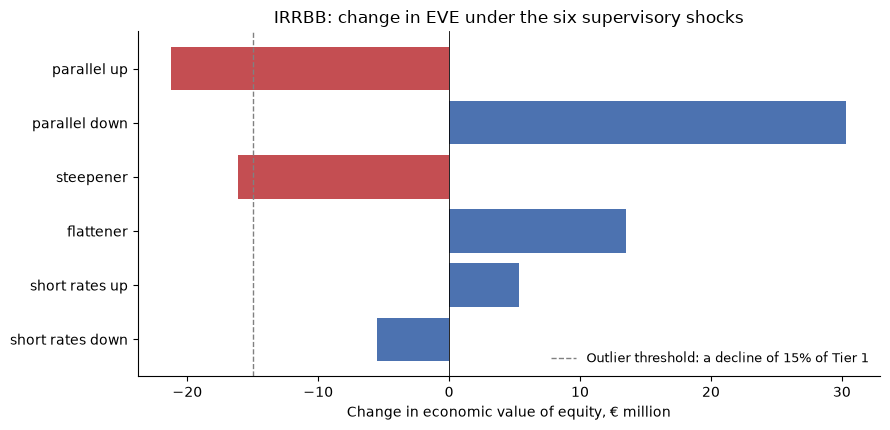

,"ΔEVE, € million","ΔEVE, % of Tier 1"
scenario,,
parallel up,-21.2,-21.2
parallel down,30.3,30.3
steepener,-16.1,-16.1
flattener,13.5,13.5
short rates up,5.3,5.3
short rates down,-5.5,-5.5


In [8]:
def cash_flows(item):
    # Times (years) and amounts (million euros) of an item's principal and interest, annual where they recur.
    amount, rate, years, kind = item["amount"], item["rate"], item["years"], item["kind"]
    if kind == "bullet":
        if years <= 0:
            return np.array([0.0]), np.array([amount])
        times = np.arange(1, int(np.ceil(years)) + 1, dtype=float) if years >= 1 else np.array([years])
        flows = np.full(len(times), amount * rate * min(years, 1.0))
        flows[-1] += amount
        return times, flows
    if kind == "annuity":
        times = np.arange(1, years + 1, dtype=float)
        return times, np.full(len(times), amount * rate / (1 - (1 + rate) ** -years))
    if kind == "spread":                                 # core deposits: repaid evenly over `years`
        times = np.arange(1, years + 1, dtype=float)
        return times, amount / years + amount * (1 - (times - 1) / years) * rate
    raise ValueError(kind)


def present_value(items, rate_at):
    total = 0.0
    for item in items.values():
        times, flows = cash_flows(item)
        total += (flows * np.exp(-rate_at(times) * times)).sum()
    return total


base_curve = AAA[-1]                                  # the AAA curve of the last day
base_rate = lambda t: np.interp(t, TENORS, base_curve)
hedge_rate = float(par_rate(base_curve, TENORS, HEDGE["maturity"]))


def eve(rate_at, hedge_notional):
    # Economic value of equity: assets minus liabilities (equity excluded) plus the banking-book hedge.
    curve_at_tenors = rate_at(TENORS)
    hedge = payer_swap_value(curve_at_tenors, TENORS, hedge_notional, hedge_rate, HEDGE["maturity"])
    return present_value(ASSETS, rate_at) - present_value(LIABILITIES, rate_at) + hedge


def shocked(name):
    return lambda t: shocked_rates(base_rate(t), t, supervisory_shocks(t)[name])


irrbb = pd.DataFrame([{"scenario": name, "ΔEVE, € million": eve(shocked(name), HEDGE["notional"]) - eve(base_rate, HEDGE["notional"])}
                      for name in supervisory_shocks(TENORS)]).set_index("scenario")
irrbb["ΔEVE, % of Tier 1"] = 100 * irrbb["ΔEVE, € million"] / TIER1
worst = irrbb["ΔEVE, € million"].idxmin()
hedge_sensitivity = pd.Series({n: 100 * min(eve(shocked(s), n) - eve(base_rate, n) for s in supervisory_shocks(TENORS)) / TIER1
                               for n in HEDGE_VARIANTS}, name="worst ΔEVE, % of Tier 1").rename_axis("hedge notional, € million")


def nii_change(shock_bp, hedge_notional=HEDGE["notional"]):
    # Change in net interest income over one year with a constant balance sheet: items repricing within the year
    # earn the shock for the rest of it; non-maturity deposits pass on DEPOSIT_PASS_THROUGH of it from day one;
    # the hedge's floating leg reprices after three months.
    change = hedge_notional * shock_bp / 1e4 * 0.75
    for sign, items in [(1, ASSETS), (-1, LIABILITIES)]:
        for name, item in items.items():
            if name.startswith("non-maturity deposits"):
                change += sign * item["amount"] * shock_bp / 1e4 * DEPOSIT_PASS_THROUGH
            elif item["kind"] == "bullet" and item["years"] <= 1:
                change += sign * item["amount"] * shock_bp / 1e4 * (1 - item["years"])
    return change


nii = pd.Series({"parallel up": nii_change(200), "parallel down": nii_change(-200)}, name="ΔNII, € million")
print(f"Worst scenario: {worst}, ΔEVE {irrbb.loc[worst, 'ΔEVE, € million']:,.1f} € million = "
      f"{irrbb.loc[worst, 'ΔEVE, % of Tier 1']:.1f}% of Tier 1 (outlier test: a decline above {100 * EVE_OUTLIER:.0f}%)")
print(f"ΔNII: parallel up {nii['parallel up']:+.1f}, parallel down {nii['parallel down']:+.1f} € million "
      f"(outlier test: a decline above {100 * NII_OUTLIER:.0f}% of Tier 1 = {NII_OUTLIER * TIER1:.0f} € million)")
display(hedge_sensitivity.round(1).to_frame())

fig, ax = plt.subplots(figsize=(9, 4.4))
colors = ["#c44e52" if v < -EVE_OUTLIER * TIER1 else "#4c72b0" for v in irrbb["ΔEVE, € million"]]
ax.barh(irrbb.index, irrbb["ΔEVE, € million"], color=colors)
ax.axvline(-EVE_OUTLIER * TIER1, color="grey", ls="--", lw=1, label="Outlier threshold: a decline of 15% of Tier 1")
ax.axvline(0, color="black", lw=0.6)
ax.legend(loc="lower right", frameon=False, fontsize=9)
ax.invert_yaxis()
ax.set(xlabel="Change in economic value of equity, € million", title="IRRBB: change in EVE under the six supervisory shocks")
fig.tight_layout()
save(fig, "q5_irrbb_eve")
plt.show()
irrbb.round(1)

## 7. Summary

In [9]:
v = var_results.set_index("VaR")
row = v.loc["VaR 99%"]
rows = [["VaR 99%, risk model", f"{row['hits']} exceptions in {row['days']} days ({100 * row['hit rate']:.1f}% against 1%); "
         f"binomial p = {p_text(row['binomial p'])}, Christoffersen p = {p_text(row['Christoffersen p'])}; zones {row['zones by year']}"],
        ["VaR 99% with the front-office risk factors", f"{v.loc['VaR 99%, front-office risk factors', 'hits']} exceptions"],
        ["Expected Shortfall 97.5%", f"Acerbi–Szekely Z2 = {z2:.2f}, p = {p_text(p_z2)}"],
        ["Stressed VaR (2022) against VaR", f"median ratio {stressed_ratio.median():.2f}"],
        ["10-day VaR: overlapping changes against the square-root rule", f"median ratio {ratio.median():.2f}"],
        ["P&L attribution, risk model against front office",
         ", ".join(f"{k}: {n}" for k, n in windows["zone"].value_counts().items()) + f" of {len(windows)} quarters; "
         f"R² of the unexplained P&L on the spread change {gap_fit.rvalue ** 2:.2f}"],
        ["IRRBB, worst ΔEVE", f"{worst}: {irrbb.loc[worst, 'ΔEVE, € million']:.1f} € million "
         f"({irrbb.loc[worst, 'ΔEVE, % of Tier 1']:.1f}% of Tier 1)"],
        ["IRRBB, worst ΔEVE by hedge size", ", ".join(f"{n:.0f}: {x:.1f}%" for n, x in hedge_sensitivity.items())],
        ["IRRBB, ΔNII", f"parallel up {nii['parallel up']:+.1f}, parallel down {nii['parallel down']:+.1f} € million"]]
summary = pd.DataFrame(rows, columns=["finding", "estimate"])
summary.to_csv(FIG / "q5_summary.csv", index=False)
pd.set_option("display.max_colwidth", 200)
summary

,finding,estimate
0,"VaR 99%, risk model","42 exceptions in 1978 days (2.1% against 1%); binomial p = <0.001, Christoffersen p = 0.070; zones 2019: yellow, 2020: red, 2021: green, 2022: yellow, 2023: green, 2024: green, 2025: yellow, 2026:..."
1,VaR 99% with the front-office risk factors,32 exceptions
2,Expected Shortfall 97.5%,"Acerbi–Szekely Z2 = -0.91, p = <0.001"
3,Stressed VaR (2022) against VaR,median ratio 1.19
4,10-day VaR: overlapping changes against the square-root rule,median ratio 0.87
5,"P&L attribution, risk model against front office","green: 26, amber: 2 of 28 quarters; R² of the unexplained P&L on the spread change 0.97"
6,"IRRBB, worst ΔEVE",parallel up: -21.2 € million (-21.2% of Tier 1)
7,"IRRBB, worst ΔEVE by hedge size","0: -50.8%, 250: -21.2%, 500: -13.3%"
8,"IRRBB, ΔNII","parallel up +3.2, parallel down -3.2 € million"
